# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Menampilkan 5 data pertama
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# INFORMASI DATASET

print("Shape Dataset :", df.shape)

print("\nInfo Dataset:")
df.info()

print("\nMissing Value:")
print(df.isnull().sum())

Shape Dataset : (7043, 21)

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  

In [5]:
# STATISTIK DESKRIPTIF

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# CEK MISSING VALUE

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
# Mengecek empty string pada TotalCharges

(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [8]:
# CEK DUPLIKAT

print("Jumlah Data Duplikat:")
print(df.duplicated().sum())

Jumlah Data Duplikat:
0


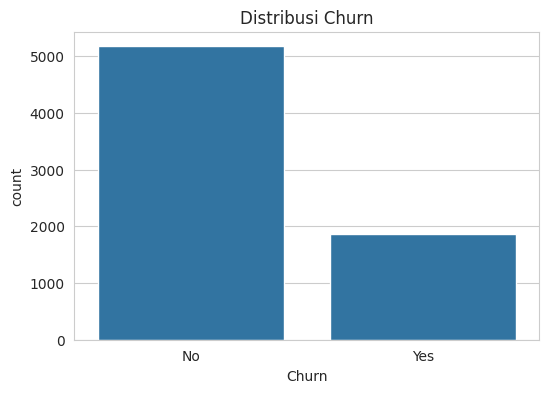

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [9]:
# DISTRIBUSI TARGET

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Distribusi Churn')
plt.show()

print(df['Churn'].value_counts())

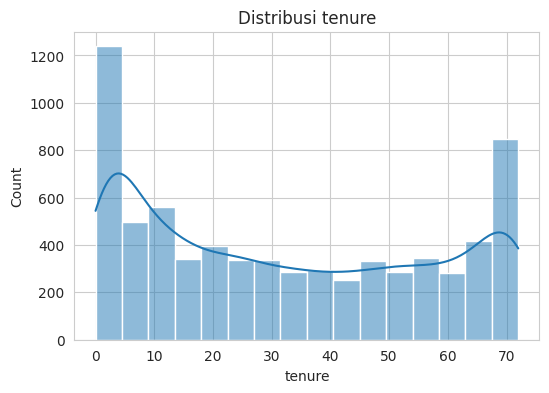

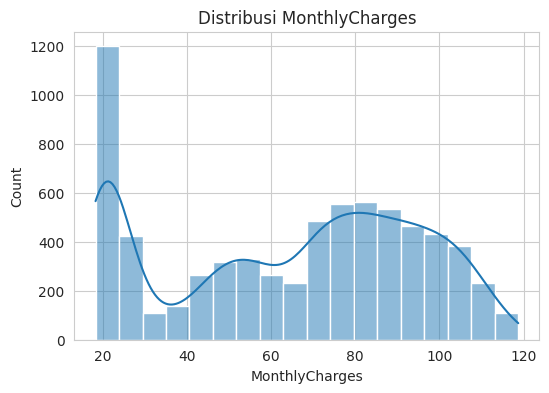

In [10]:
# DISTRIBUSI FITUR NUMERIK

numerical_cols = [
    'tenure',
    'MonthlyCharges'
]

for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Distribusi {col}')
    plt.show()

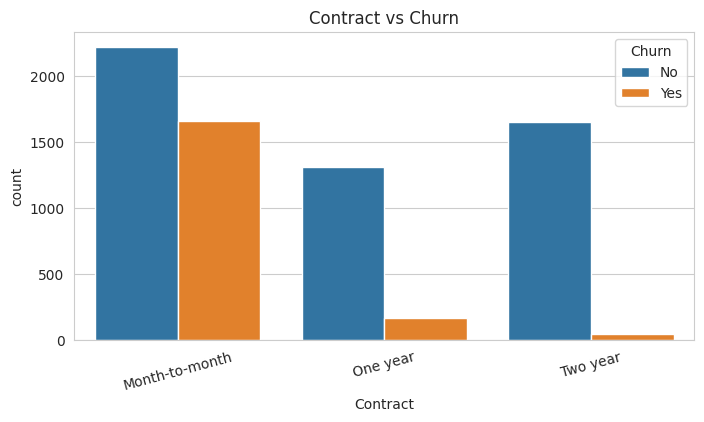

In [11]:
# CONTRACT VS CHURN

plt.figure(figsize=(8,4))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Contract vs Churn')
plt.xticks(rotation=15)
plt.show()

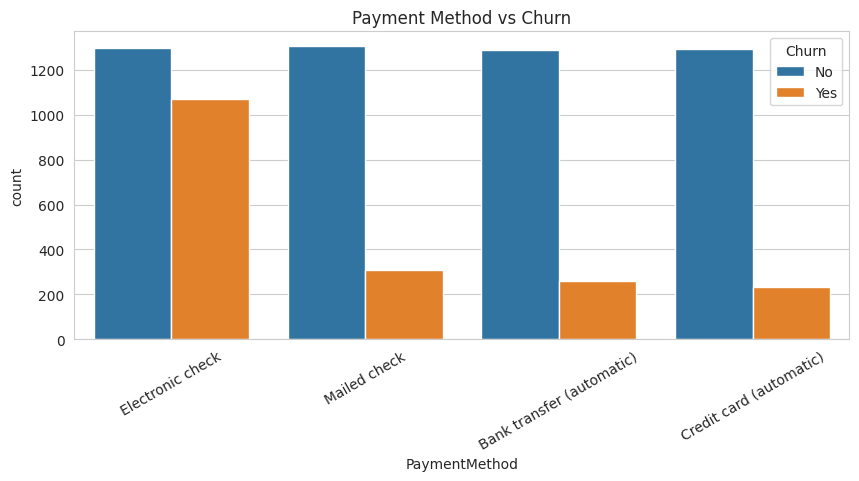

In [12]:
# PAYMENT METHOD VS CHURN

plt.figure(figsize=(10,4))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.title('Payment Method vs Churn')
plt.xticks(rotation=30)
plt.show()

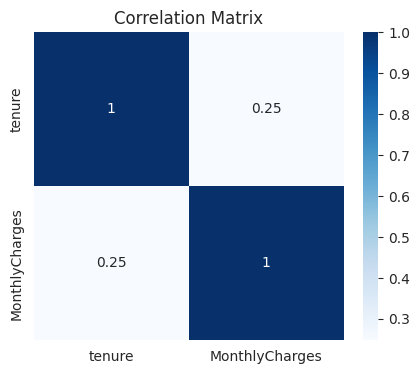

In [13]:
# KORELASI NUMERIK

corr = df[
    ['tenure', 'MonthlyCharges']
].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Matrix')
plt.show()

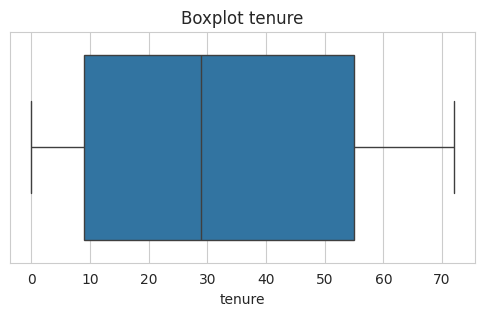

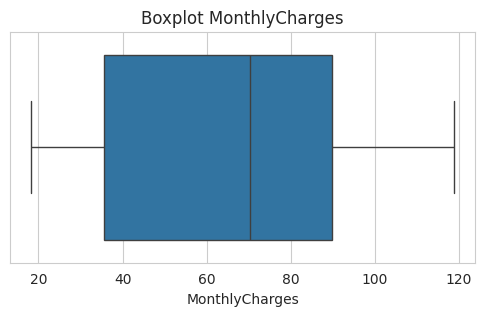

In [14]:
# DETEKSI OUTLIER

numerical_cols = [
    'tenure',
    'MonthlyCharges'
]

for col in numerical_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot {col}')

    plt.show()

Berdasarkan hasil EDA diperoleh beberapa insight:

1. Dataset memiliki kombinasi fitur numerik dan kategorikal.
2. Terdapat missing value tersembunyi pada kolom TotalCharges berupa empty string.
3. Distribusi target Churn cenderung imbalance.
4. Fitur Contract dan PaymentMethod terlihat memiliki hubungan terhadap churn pelanggan.
5. Beberapa fitur numerik memiliki indikasi outlier sehingga perlu diperhatikan pada tahap preprocessing.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [15]:
# MISSING VALUE HANDLING

# Mengubah empty string menjadi NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Konversi ke numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Mengecek missing value
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [16]:
# Mengisi missing value dengan median

df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [18]:
# DROP KOLOM TIDAK RELEVAN

df.drop('customerID', axis=1, inplace=True)

In [19]:
# PENANGANAN OUTLIER DENGAN IQR

numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

print("Ukuran dataset setelah penanganan outlier:")
print(df.shape)

Ukuran dataset setelah penanganan outlier:
(7043, 20)


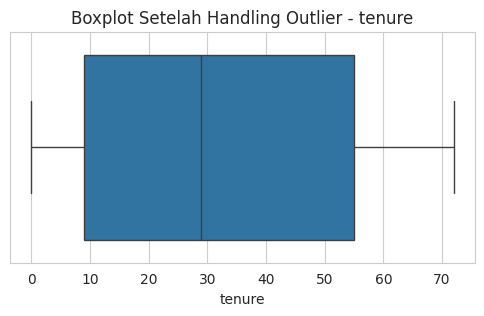

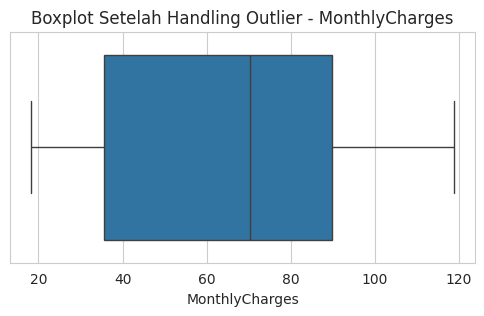

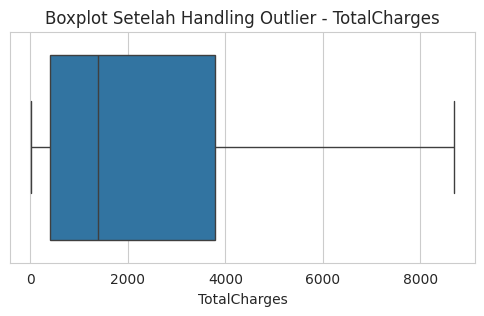

In [20]:
# VISUALISASI SETELAH PENANGANAN OUTLIER

for col in numerical_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot Setelah Handling Outlier - {col}')

    plt.show()

In [21]:
# BINNING TENURE

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=[
        '0-12',
        '13-24',
        '25-48',
        '49-72'
    ]
)

df['TenureGroup'].value_counts()

,count
TenureGroup,
49-72,2239
0-12,2175
25-48,1594
13-24,1024


In [22]:
# ENCODING TARGET

le = LabelEncoder()

df['Churn'] = le.fit_transform(df['Churn'])

In [23]:
# ONE HOT ENCODING

df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49-72
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False


In [24]:
# FEATURE SCALING

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49-72
0,-0.439916,-1.277445,-1.160323,-0.994242,-1.009559,1.034530,-0.654012,-3.054010,3.054010,-0.854176,...,-0.79607,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807,-0.412466,-0.540861,-0.682693
1,-0.439916,0.066327,-0.259629,-0.173244,0.990532,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.79607,1.944582,-0.562975,-1.205113,-0.525047,-0.711026,1.835513,-0.412466,1.848904,-0.682693
2,-0.439916,-1.236724,-0.362660,-0.959674,0.990532,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.79607,-0.514249,-0.562975,0.829798,-0.525047,-0.711026,1.835513,-0.412466,-0.540861,-0.682693
3,-0.439916,0.514251,-0.746535,-0.194766,0.990532,-0.966622,-0.654012,-3.054010,3.054010,-0.854176,...,-0.79607,1.944582,-0.562975,-1.205113,-0.525047,-0.711026,-0.544807,-0.412466,1.848904,-0.682693
4,-0.439916,-1.236724,0.197365,-0.940470,-1.009559,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.79607,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807,-0.412466,-0.540861,-0.682693


In [25]:
# SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_scaled,
    y
)

print("Distribusi Sebelum SMOTE:")
print(y.value_counts())

print("\nDistribusi Setelah SMOTE:")
print(pd.Series(y_resampled).value_counts())

Distribusi Sebelum SMOTE:
Churn
0    5174
1    1869
Name: count, dtype: int64

Distribusi Setelah SMOTE:
Churn
0    5174
1    5174
Name: count, dtype: int64


In [26]:
# DATASET FINAL

final_df = pd.concat([
    pd.DataFrame(
        X_resampled,
        columns=X.columns
    ),

    pd.Series(
        y_resampled,
        name='Churn'
    )
], axis=1)

final_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49-72,Churn
0,-0.439916,-1.277445,-1.160323,-0.994242,-1.009559,1.034530,-0.654012,-3.054010,3.054010,-0.854176,...,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807,-0.412466,-0.540861,-0.682693,0
1,-0.439916,0.066327,-0.259629,-0.173244,0.990532,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,1.944582,-0.562975,-1.205113,-0.525047,-0.711026,1.835513,-0.412466,1.848904,-0.682693,0
2,-0.439916,-1.236724,-0.362660,-0.959674,0.990532,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.514249,-0.562975,0.829798,-0.525047,-0.711026,1.835513,-0.412466,-0.540861,-0.682693,1
3,-0.439916,0.514251,-0.746535,-0.194766,0.990532,-0.966622,-0.654012,-3.054010,3.054010,-0.854176,...,1.944582,-0.562975,-1.205113,-0.525047,-0.711026,-0.544807,-0.412466,1.848904,-0.682693,0
4,-0.439916,-1.236724,0.197365,-0.940470,-1.009559,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,...,-0.514249,-0.562975,0.829798,-0.525047,1.406418,-0.544807,-0.412466,-0.540861,-0.682693,1


In [27]:
# SAVE PREPROCESSED DATASET

final_df.to_csv(
    'telco_preprocessed.csv',
    index=False
)

print("Dataset preprocessing berhasil disimpan.")

Dataset preprocessing berhasil disimpan.
